# O-burning

Oxygen burning primarily takes place via:

$$\begin{split}{}^{16}\mathrm{O} + {}^{16}\mathrm{O} \rightarrow \begin{cases}
       {}^{28}\mathrm{Si} + \alpha \\
       {}^{31}\mathrm{P} + p \\
       {}^{31}\mathrm{S} + n \end{cases}
\end{split}$$

In [8]:
import pynucastro as pyna

```{note}
There are several libraries that provide compilations of reaction rates.  Two popular ones are 
[ReacLib](https://reaclib.jinaweb.org/) and [StarLib](https://starlib.github.io/Rate-Library/).  Both provide
~ 80k rates for a variety of nuclear processes.

MESA uses ReacLib for rates, so that will be our source for the O-burning rates.
```

In [9]:
rl = pyna.ReacLibLibrary()
rates = rl.get_rate_by_name(["o16(o16,a)si28",
                             "o16(o16,p)p31",
                             "o16(o16,n)s31"])

In [10]:
import numpy as np
import matplotlib.pyplot as plt

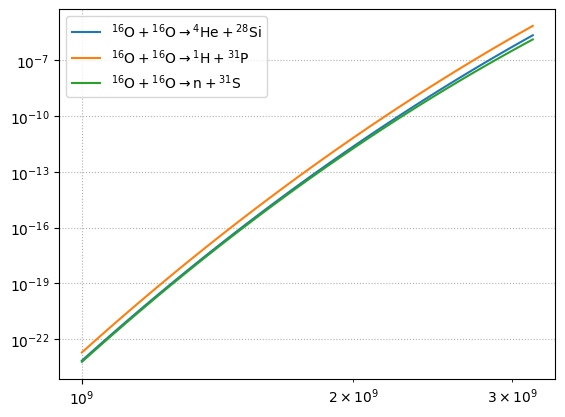

In [30]:
fig, ax = plt.subplots()
Ts = np.logspace(9, 9.5, 100)

for r in rates:
    ax.loglog(Ts, [r.eval(T) for T in Ts], label=f"{r.pretty_string}")

ax.grid(ls=":")
ax.legend()

Notice that the branching that emits a neutron is the slowest.  It is also the least energetic

In [29]:
for r in rates:
    print(f"{r!s:30} : {r.Q} MeV")

O16 + O16 ⟶ He4 + Si28         : 9.593 MeV
O16 + O16 ⟶ p + P31            : 7.678 MeV
O16 + O16 ⟶ n + S31            : 1.5 MeV


for this reason, it is often neglected.

We can also check the temperature sensitivity, by expressing the rate as:

$$r = r_0 \left ( \frac{T}{T_0} \right )^\nu$$

exploring various $T_0$, we find:

In [33]:
for T0 in [5.e8, 1.e9, 2.e9, 4.e9]:
    nu = rates[0].get_rate_exponent(T0)
    print(f"{T0:6.2g} : {nu:5.2f}")

 5e+08 : 55.96
 1e+09 : 43.64
 2e+09 : 33.24
 4e+09 : 23.75


This is extremely temperature sensitive.

## Approximate O burning

We can approximate O-burning by assuming that the ${}^{31}\mathrm{P}$ nucleus is in equilibrium.

In [34]:
net = pyna.network_helper(["p", "he4", "o16", "si28", "p31", "s32"])

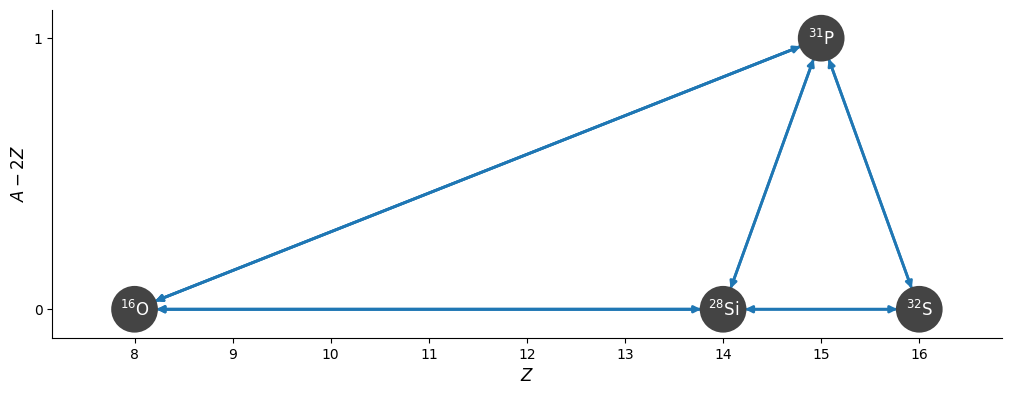

In [40]:
fig = net.plot(rotated=True, size=(1000, 400))

The idea is to take $dY({}^{31}\mathrm{P})/dt = 0$

In [42]:
dydt = net.full_ydot_string(pyna.Nucleus("p31"))
print(dydt)

dYdt[jp31] = (
      ( -rho*Y[jp]*Y[jp31]*rate_eval.p_P31_to_S32_reaclib +Y[js32]*rate_eval.S32_to_p_P31_derived ) +
      ( +5.00000000000000e-01*rho*Y[jo16]**2*rate_eval.O16_O16_to_p_P31_reaclib -rho*Y[jp]*Y[jp31]*rate_eval.p_P31_to_O16_O16_derived ) +
      ( -rho*Y[jp]*Y[jp31]*rate_eval.p_P31_to_He4_Si28_reaclib +rho*Y[jhe4]*Y[jsi28]*rate_eval.He4_Si28_to_p_P31_derived )
   )




we can solve for the equilibrium abundance of $Y({}^{31}\mathrm{P})$ and approximate it out.

In [43]:
net.make_CO_burning_approx("O")
net.remove_nuclei(["p31"])

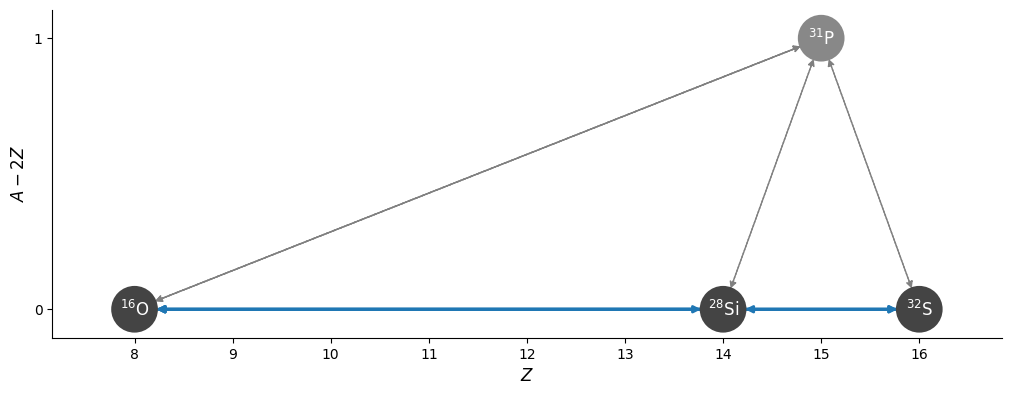

In [44]:
fig = net.plot(rotated=True, size=(1000, 400))

We'll use the approximate rate for ${}^{16}\mathrm{O}({}^{16}\mathrm{O},\alpha){}^{28}\mathrm{Si}$

In [45]:
r1616 = net.get_rate_by_name("o16(o16,a)si28")
print(r1616.function_string_py())

@numba.njit()
def O16_O16_to_Si28_He4_approx(rate_eval, tf):
    r_pY = rate_eval.p_P31_to_O16_O16_derived
    r_pa = rate_eval.p_P31_to_He4_Si28_reaclib
    r_pg = rate_eval.p_P31_to_S32_reaclib
    denom = r_pY + r_pa + r_pg
    r_Ya = rate_eval.O16_O16_to_He4_Si28_reaclib
    r_Yp = rate_eval.O16_O16_to_p_P31_reaclib
    rate = r_Ya + r_Yp * r_pa / denom
    rate_eval.O16_O16_to_Si28_He4_approx = rate




This combines ${}^{16}\mathrm{O}({}^{16}\mathrm{O},\alpha){}^{28}\mathrm{Si}$ + ${}^{16}\mathrm{O}({}^{16}\mathrm{O},p){}^{31}\mathrm{P}(p,\alpha){}^{28}\mathrm{Si}$

## Timescales

We can compute the timescale for burning as

$$\tau \sim \frac{1}{|\dot{X}|}$$

In [ ]:
net = pyna.PythonNetwork(rates=[r1616])

In [73]:
rhos = np.logspace(7, 10, 7)
Ts = np.logspace(8.75, 10, 31)

comp = pyna.Composition(net.unique_nuclei)
comp.X[pyna.Nucleus("o16")] = 0.5
comp.X[pyna.Nucleus("ne20")] = 0.5

In [74]:
o16 = pyna.Nucleus("o16")

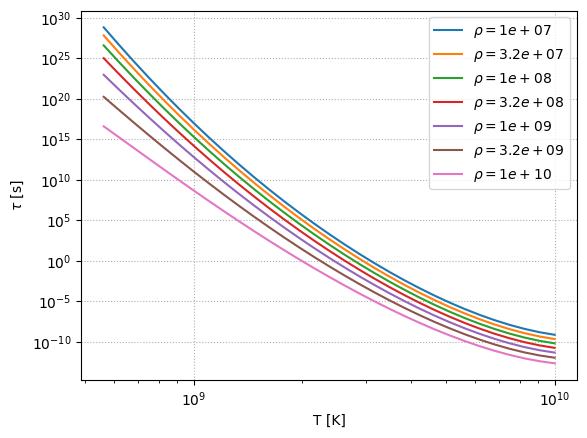

In [75]:
fig, ax = plt.subplots()

for rho in rhos:
    xdots = np.array([net.evaluate_ydots(rho, T, comp,
                                         screen_func=pyna.screening.screen.chugunov_2007)[o16] * o16.A
                      for T in Ts])
    ax.loglog(Ts, 1.0 / np.abs(xdots), label=rf"$\rho = {rho:6.2g}$")
ax.grid(ls=":")
ax.set_xlabel("T [K]")
ax.set_ylabel(r"$\tau$ [s]")
ax.legend()